<a href="https://colab.research.google.com/github/sele1888/Data_Science_Project/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (150000, 12)
   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                        

/tmp/ipykernel_19894/2934526786.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["MonthlyIncome"].fillna(df["MonthlyIncome"].median(), inplace=True)
/tmp/ipykernel_19894/2934526786.py:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

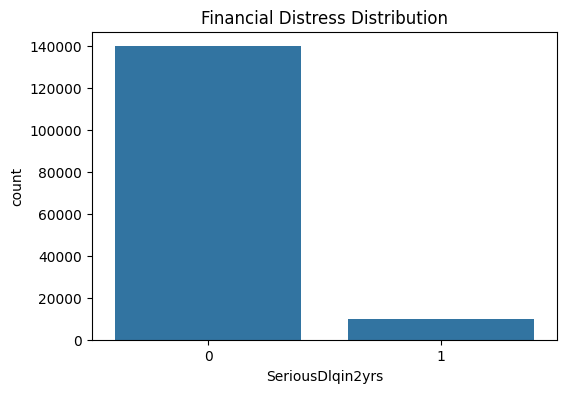

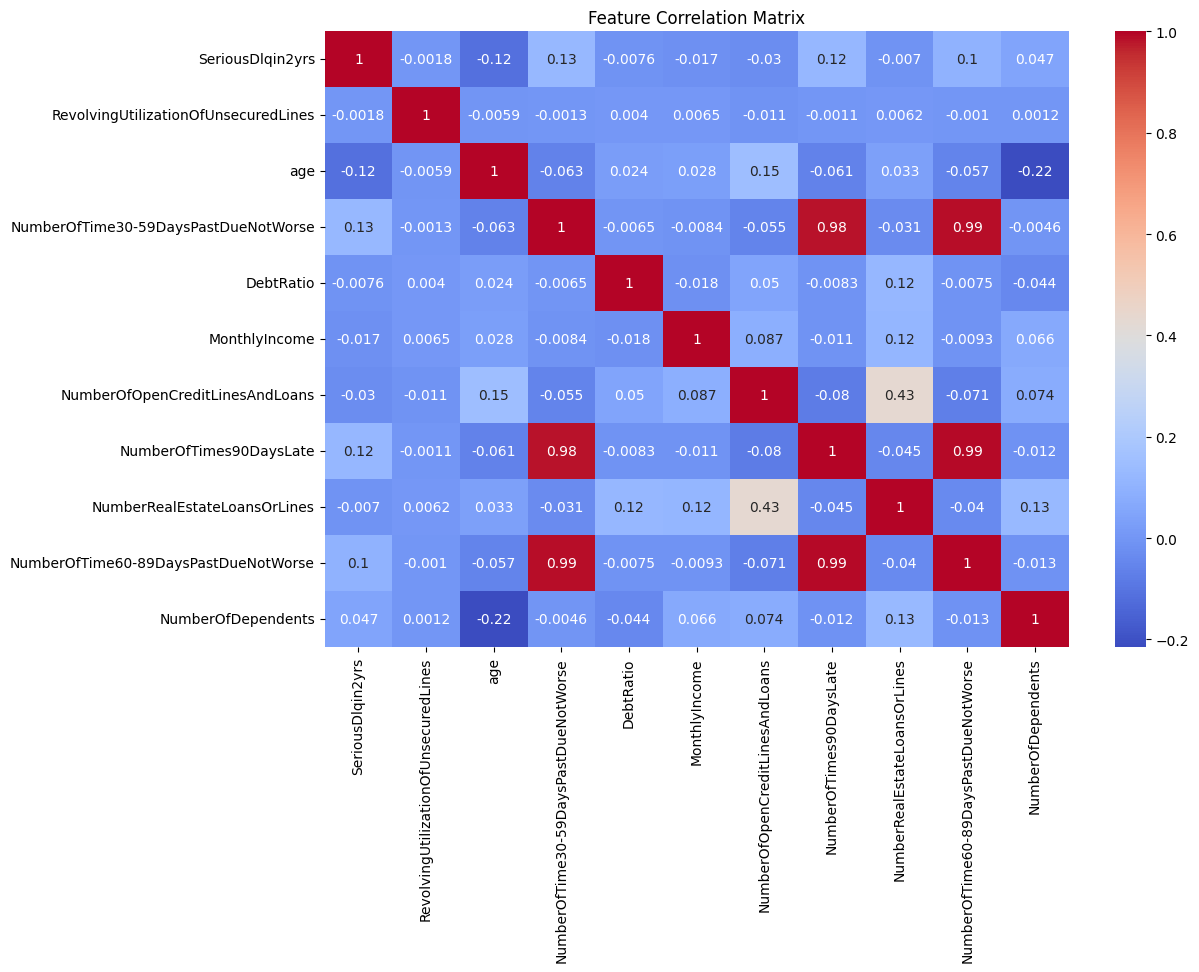

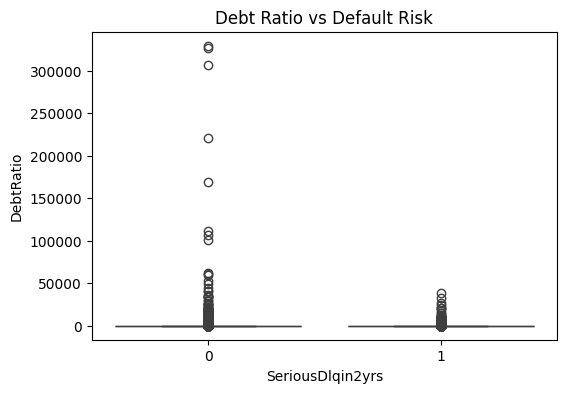

Accuracy Score: 0.9350333333333334

Confusion Matrix:

[[27975    69]
 [ 1880    76]]

Classification Report:

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     28044
           1       0.52      0.04      0.07      1956

    accuracy                           0.94     30000
   macro avg       0.73      0.52      0.52     30000
weighted avg       0.91      0.94      0.91     30000



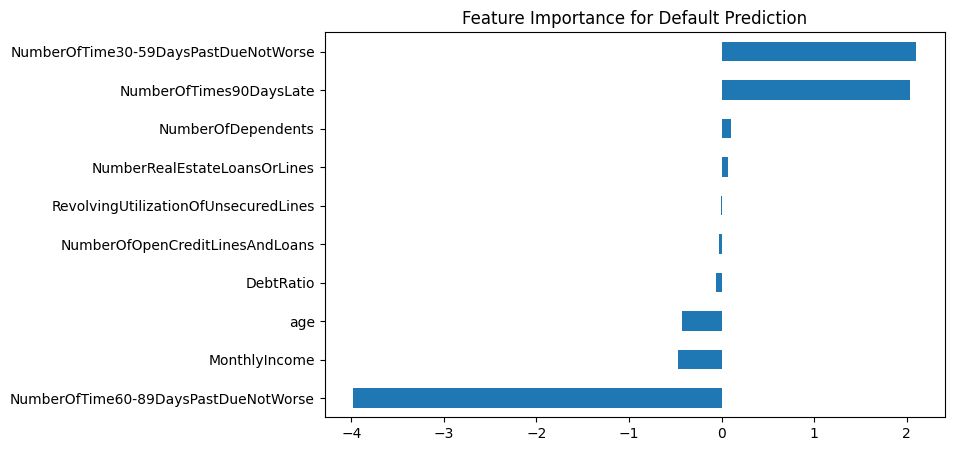

In [3]:
# ======================================
# STEP 1: Import Libraries
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#scikit-learn =============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# STEP 2: Load Dataset
# ======================================

df = pd.read_csv("/content/drive/MyDrive/Dataset/cs-training.csv")

print("Dataset Shape:", df.shape)
print(df.head())


# ======================================
# STEP 3: Drop ID Column
# ======================================

df.drop("Unnamed: 0", axis=1, inplace=True)


# ======================================
# STEP 4: Check Missing Values
# ======================================

print("\nMissing Values:\n", df.isnull().sum())


# ======================================
# STEP 5: Handle Missing Data
# ======================================

df["MonthlyIncome"].fillna(df["MonthlyIncome"].median(), inplace=True)

df["NumberOfDependents"].fillna(
    df["NumberOfDependents"].median(),
    inplace=True
)


# ======================================
# STEP 6: Dataset Overview
# ======================================

print(df.info())

print(df.describe())


# ======================================
# STEP 7: Target Variable Distribution
# ======================================

plt.figure(figsize=(6,4))

sns.countplot(x="SeriousDlqin2yrs", data=df)

plt.title("Financial Distress Distribution")

plt.show()


# ======================================
# STEP 8: Correlation Heatmap
# ======================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()


# ======================================
# STEP 9: Important Feature Visualization
# ======================================

plt.figure(figsize=(6,4))

sns.boxplot(
    x=df["SeriousDlqin2yrs"],
    y=df["DebtRatio"]
)

plt.title("Debt Ratio vs Default Risk")

plt.show()


# ======================================
# STEP 10: Feature Selection
# ======================================

X = df.drop("SeriousDlqin2yrs", axis=1)

y = df["SeriousDlqin2yrs"]


# ======================================
# STEP 11: Train/Test Split
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ======================================
# STEP 12: Feature Scaling
# ======================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# ======================================
# STEP 13: Train Model
# ======================================

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


# ======================================
# STEP 14: Prediction
# ======================================

y_pred = model.predict(X_test)


# ======================================
# STEP 15: Model Evaluation
# ======================================

print("Accuracy Score:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n")

print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


# ======================================
# STEP 16: Feature Importance Insight
# ======================================

importance = pd.Series(
    model.coef_[0],
    index=df.drop("SeriousDlqin2yrs", axis=1).columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance for Default Prediction")

plt.show()